In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Load dataset
df = pd.read_csv(r"C:\Users\venne\Downloads\New Afficionado Coffee Roasters.csv")

# Check missing values
print(df.isnull().sum())

# Check duplicate transactions
duplicates = df["transaction_id"].duplicated().sum()
print("Duplicate transactions:", duplicates)

# Validate logical consistency
df = df[(df["transaction_qty"] > 0) & (df["unit_price"] > 0)]

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64
Duplicate transactions: 0


In [20]:
# Convert transaction time
df["transaction_time"] = pd.to_datetime(df["transaction_time"], format="mixed")

# Create synthetic date within the year
df["date"] = pd.date_range(
    start="2025-01-01",
    periods=len(df),
    freq="min"
)

# Extract weekday
df["day_of_week"] = df["date"].dt.day_name()

In [21]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]
#Hour of Day
df["hour"] = df["transaction_time"].dt.hour
print(df["revenue"])
print(df["hour"])

0         6.00
1         6.20
2         9.00
3         2.00
4         6.20
          ... 
149111    5.00
149112    6.00
149113    3.00
149114    3.75
149115    1.60
Name: revenue, Length: 149116, dtype: float64
0          7
1          7
2          7
3          7
4          7
          ..
149111    20
149112    20
149113    20
149114    20
149115    20
Name: hour, Length: 149116, dtype: int32


In [22]:
#Time Buckets
def time_bucket(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 21:
        return "Evening"
    else:
        return "Late Hours"

df["time_bucket"] = df["hour"].apply(time_bucket)
print(df["time_bucket"])

0         Morning
1         Morning
2         Morning
3         Morning
4         Morning
           ...   
149111    Evening
149112    Evening
149113    Evening
149114    Evening
149115    Evening
Name: time_bucket, Length: 149116, dtype: object


In [23]:
#Daily Revenue Trend
daily_revenue = df.groupby("date")["revenue"].sum()
#Weekly Aggregation
weekly_revenue = df.groupby(df["date"].dt.isocalendar().week)["revenue"].sum()
weekly_transactions = df.groupby(df["date"].dt.isocalendar().week)["transaction_id"].count()

In [24]:
#Revenue by Day
dow_revenue = df.groupby("day_of_week")["revenue"].mean().sort_values(ascending=False)
#Transactions by Day
dow_transactions = df.groupby("day_of_week")["transaction_id"].count()
#Weekday vs Weekend
df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

weekend_analysis = df.groupby("day_type")["revenue"].sum()

print("Revenue by Day:")
print(dow_revenue.head())

print("\n Transactions by Day:")
print(dow_transactions.head())

print("\nWeekend and Weekday Revenue:")
print(weekend_analysis.head())

Revenue by Day:
day_of_week
Thursday     4.778620
Monday       4.722649
Tuesday      4.704184
Wednesday    4.676756
Friday       4.673049
Name: revenue, dtype: float64

 Transactions by Day:
day_of_week
Friday      21600
Monday      20956
Saturday    21600
Sunday      21600
Thursday    21600
Name: transaction_id, dtype: int64

Weekend and Weekday Revenue:
day_type
Weekday    498978.17
Weekend    199834.16
Name: revenue, dtype: float64


In [25]:
#Hourly Transactions
hourly_transactions = df.groupby("hour")["transaction_id"].count()
#Hourly Revenue
hourly_revenue = df.groupby("hour")["revenue"].sum()

print("\nHourly Transactions:")
print(hourly_transactions.head())


Hourly Transactions:
hour
6      4594
7     13428
8     17654
9     17764
10    18545
Name: transaction_id, dtype: int64


In [26]:
#Revenue by Store Location
store_revenue = df.groupby("store_location")["revenue"].sum()
#Hourly Heatmap Data
store_hour_heatmap = df.pivot_table(
    values="revenue",
    index="store_location",
    columns="hour",
    aggfunc="sum"
)

print("\nRevenue by Store Location:")
print(store_revenue.head())

print("\nStore Hour Heatmap:")
print(store_hour_heatmap)


Revenue by Store Location:
store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64

Store Hour Heatmap:
hour                   6         7         8         9         10        11  \
store_location                                                                
Astoria               NaN  19028.80  22805.90  23183.57  24426.12  15498.13   
Hell's Kitchen    7531.17  15961.05  31544.44  32874.29  33605.81  17926.54   
Lower Manhattan  14369.10  28536.62  28349.53  29111.67  30641.46  12894.47   

hour                   12        13        14        15        16        17  \
store_location                                                                
Astoria          15681.20  15947.87  15175.27  15651.95  16110.85  15839.30   
Hell's Kitchen   11343.10  12070.10  12297.50  11311.25  11990.48  12789.50   
Lower Manhattan  13168.49  12349.48  13831.97  14769.90  13021.42  11505.51   

hour                   18  

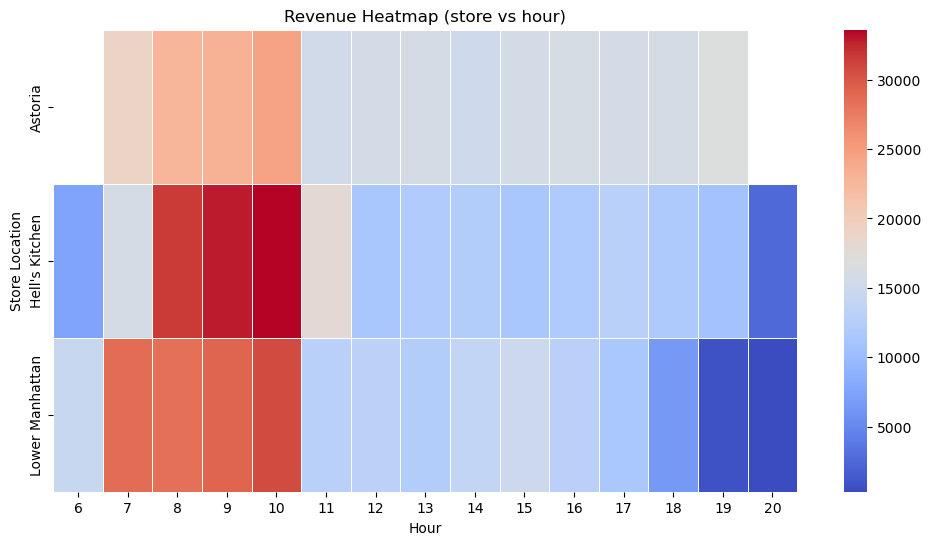

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(store_hour_heatmap,cmap="coolwarm", linewidths=0.5)

plt.title("Revenue Heatmap (store vs hour)")
plt.xlabel("Hour")
plt.ylabel("Store Location")
plt.show()

In [31]:
df.to_csv('Final_Project_Afficionado Coffee Roasters.csv')